In [3]:
import pandas as pd
import numpy as np

#Q1

In [4]:
df=pd.read_csv("ovariantotal.csv")

In [5]:
df.head()

,AFP,AG,Age,ALB,ALP,ALT,AST,BASO#,BASO%,BUN,...,PCT,PDW,PHOS,PLT,RBC,RDW,TBIL,TP,UA,TYPE
0,3.58,19.36,47,45.4,56,11,24,0.01,0.30,5.35,...,0.09,13.4,1.46,74,2.64,13.7,5.5,73.9,396.4,0
1,34.24,23.98,61,39.9,95,9,13,0.02,0.30,3.21,...,0.30,11.2,1.09,304,4.89,12.7,6.8,72.0,119.2,0
2,1.50,18.40,39,45.4,77,9,18,0.03,0.60,3.80,...,0.13,15.2,0.97,112,4.62,12.0,14.8,77.9,209.2,0
3,2.75,16.60,45,39.2,26,16,17,0.05,0.74,5.27,...,0.25,17.4,1.25,339,4.01,14.6,10.9,66.1,215.6,0
4,2.36,19.97,45,35.0,47,21,27,0.01,0.10,4.89,...,0.28,11.9,0.94,272,4.40,13.4,5.3,66.5,206.0,0


In [6]:
df.shape

(349, 50)

In [7]:
X=df.drop('TYPE',axis=1)
y=df["TYPE"]

In [8]:
X["Age"].max()

83

##Normalise using MIN-MAX scalar

fit$(x) ->$ Calculates min and max values for each feature

transform$(x) ->$ Applies the following formula to each value in X:

$\displaystyle X_{scaled}=\frac{x-x_{min}}{x_{max}-x_{min}}$

In [9]:
from sklearn import preprocessing
min_max=preprocessing.MinMaxScaler()
X_scale=min_max.fit_transform(X)
X_scale

array([[2.45578349e-03, 4.85071876e-01, 4.70588235e-01, ...,
        8.37988827e-02, 7.60667904e-01, 5.60447761e-01],
       [2.78074070e-02, 6.55363067e-01, 6.76470588e-01, ...,
        1.20111732e-01, 7.25417440e-01, 4.32835821e-02],
       [7.35908185e-04, 4.49686694e-01, 3.52941176e-01, ...,
        3.43575419e-01, 8.34879406e-01, 2.11194030e-01],
       ...,
       [1.83563615e-03, 4.80280133e-01, 6.47058824e-01, ...,
        3.15642458e-01, 6.58627087e-01, 2.11753731e-01],
       [1.01704165e-03, 7.74788058e-01, 2.20588235e-01, ...,
        2.45810056e-01, 7.99628942e-01, 3.53917910e-01],
       [8.26863129e-04, 2.50645042e-01, 3.52941176e-01, ...,
        1.62011173e-01, 6.62337662e-01, 1.65858209e-01]])

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_scale,y,test_size=0.2,random_state=0)

In [11]:
X_train.shape

(279, 49)

In [12]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense

Sequential $->$ The o/p of $h_i$ is i/p to $h_j$ (j = i++)

Dense $->$ Each Neuron is connected to each neuron

In [13]:
model=Sequential()
model.add(Dense(32,activation='relu',input_dim=49))
model.add(Dense(32,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.fit(X_train,y_train,batch_size=32,epochs=15)

Epoch 1/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5341 - loss: 0.6793
Epoch 2/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5986 - loss: 0.6703 
Epoch 3/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6344 - loss: 0.6579 
Epoch 4/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6559 - loss: 0.6427 
Epoch 5/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7599 - loss: 0.6235 
Epoch 6/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7921 - loss: 0.6028 
Epoch 7/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8029 - loss: 0.5769 
Epoch 8/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7706 - loss: 0.5517 
Epoch 9/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7993 - loss: 0.5242 
Epoch 10/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7993 - loss: 0.5033 
Epoch 11/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8100 - loss: 0.4841  
Epoch 12/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8136 - loss: 0.4672 
E

In [15]:
y_pred=model.predict(X_test)
y_pred

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


array([[0.68324953],
       [0.2517848 ],
       [0.65279233],
       [0.10129458],
       [0.87220293],
       [0.89712507],
       [0.86069185],
       [0.20590732],
       [0.11310089],
       [0.80781037],
       [0.6535715 ],
       [0.16640452],
       [0.85497195],
       [0.28092912],
       [0.09965041],
       [0.5117449 ],
       [0.64405805],
       [0.77096754],
       [0.91265017],
       [0.4482275 ],
       [0.68111175],
       [0.7045606 ],
       [0.21908943],
       [0.8662665 ],
       [0.06010051],
       [0.79323405],
       [0.03376058],
       [0.11293703],
       [0.07622435],
       [0.8469972 ],
       [0.43644643],
       [0.39467442],
       [0.07592506],
       [0.20087926],
       [0.15191342],
       [0.0252019 ],
       [0.6628735 ],
       [0.75030667],
       [0.14811759],
       [0.31275594],
       [0.88644683],
       [0.8012675 ],
       [0.8572316 ],
       [0.79028547],
       [0.80986667],
       [0.04311288],
       [0.28770876],
       [0.710

In [16]:
y_pred.shape

(70, 1)

In [17]:
y_test.shape

(70,)

In [18]:
y_pred=np.where(y_pred<0.5,0,1)
y_pred=y_pred.astype(int)
np.column_stack((y_pred,y_test))

array([[1, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 0],
       [1, 0],
       [1, 1],
       [1, 1],
       [0, 1],
       [1, 1],
       [1, 1],
       [0, 0],
       [1, 0],
       [0, 0],
       [1, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [1, 1],
       [1, 1],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 0],
       [1, 1],
       [0, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 0],
       [1, 1],
       [0, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [0,

In [19]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[33  8]
 [ 3 26]]
0.8428571428571429


#Breast Cancer Wisconsin Diagnostic Dataset

##Quick Overview of Data-set

In [20]:
import pandas as pd
df=pd.read_csv('breast-cancer-wisconsin-data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [21]:
df.shape

(569, 32)

In [22]:
df['diagnosis'] = df['diagnosis'].replace({'M': 1, 'B': 0})
X=df.drop('diagnosis',axis=1)
y=df['diagnosis']
y.sample(5)

/tmp/ipykernel_623/944750201.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['diagnosis'] = df['diagnosis'].replace({'M': 1, 'B': 0})


,diagnosis
446,1
269,0
132,1
229,1
473,0


##Normalize and split the Data-set

In [23]:
from sklearn.preprocessing import StandardScaler
stdScalar=StandardScaler()
X_scaled=stdScalar.fit_transform(X)

In [24]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=0)
y_train.shape

(455,)

##Build the Model

In [25]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense

In [26]:
model=Sequential()
model.add(Dense(32,activation='relu',input_dim=31))
model.add(Dense(32,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
history=model.fit(X_train,y_train,batch_size=32,epochs=50)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7495 - loss: 0.5145
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9165 - loss: 0.3322 
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9451 - loss: 0.2281 
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9582 - loss: 0.1681 
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9670 - loss: 0.1334 
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9736 - loss: 0.1128 
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9780 - loss: 0.0985 
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9802 - loss: 0.0886 
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9802 - loss: 0.0804 
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9802 - loss: 0.0744 
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9824 - loss: 0.0700 
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0

##Test the model

In [28]:
y_pred=model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [29]:
import numpy as np
y_pred=np.where(y_pred<0.5,0,1)
y_pred=y_pred.astype(int)
np.column_stack((y_pred,y_test))

array([[1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 0],
       [0, 0],
       [0, 0],
       [1, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [1, 1],
       [1, 1],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [1, 1],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1,

In [30]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[63  4]
 [ 1 46]]
0.956140350877193


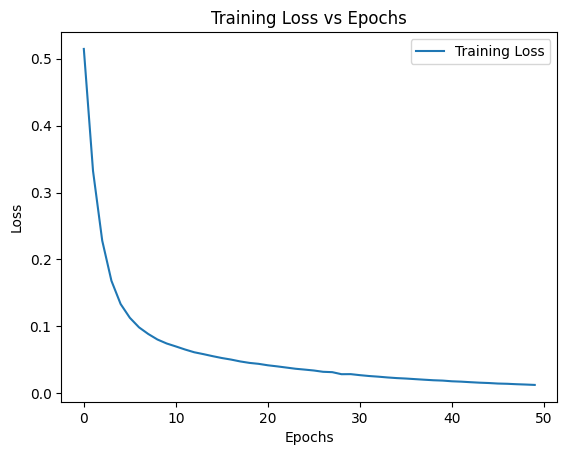

In [31]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.title('Training Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

##Training my model with Early-Stopping

In [32]:
from keras.callbacks import EarlyStopping

model2=Sequential()
model2.add(Dense(32,activation='relu',input_dim=31))
model2.add(Dense(32,activation='relu'))
model2.add(Dense(1,activation='sigmoid'))

model2.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
early_stop=EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)
history=model2.fit(X_train,y_train,batch_size=32,epochs=50,validation_split=0.2,callbacks=[early_stop],verbose=1)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7060 - loss: 0.5523 - val_accuracy: 0.9121 - val_loss: 0.4088
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9478 - loss: 0.3587 - val_accuracy: 0.9670 - val_loss: 0.2750
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9643 - loss: 0.2476 - val_accuracy: 0.9890 - val_loss: 0.1947
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9670 - loss: 0.1808 - val_accuracy: 0.9890 - val_loss: 0.1450
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9725 - loss: 0.1405 - val_accuracy: 0.9890 - val_loss: 0.1140
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9753 - loss: 0.1166 - val_accuracy: 0.9890 - val_loss: 0.0948
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9753 - loss: 0.1013 - val_accuracy: 0.9890 - val_loss: 0.0820
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9780 - loss: 0.0909 - val_accuracy: 0.9890 - val_loss: 0.073

In [33]:
y_pred=model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [34]:
import numpy as np
y_pred=np.where(y_pred<0.5,0,1)  #IMPORTANT
y_pred=y_pred.astype(int)        #IMPORTANT
np.column_stack((y_pred,y_test))

array([[1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 0],
       [0, 0],
       [0, 0],
       [1, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [1, 1],
       [1, 1],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [1, 1],
       [1, 1],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [1, 1],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [1, 1],
       [1, 1],
       [1, 1],
       [0, 0],
       [0, 0],
       [1, 1],
       [0, 0],
       [1,

In [35]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[63  4]
 [ 1 46]]
0.956140350877193


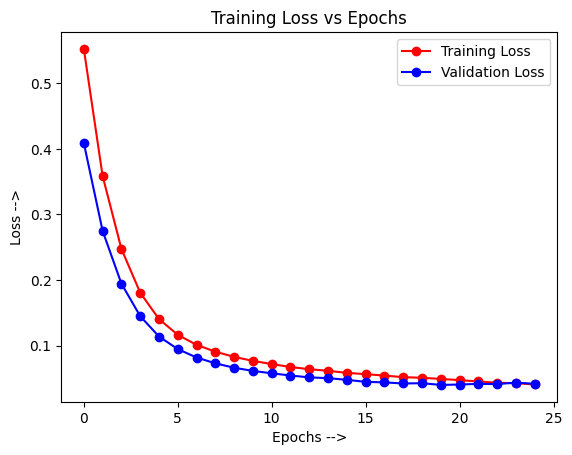

In [36]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'],color='r',marker='o', label='Training Loss')
plt.plot(history.history['val_loss'],color='b',marker='o', label='Validation Loss')
plt.title('Training Loss vs Epochs')
plt.xlabel('Epochs -->')
plt.ylabel('Loss -->')
plt.legend()
plt.show()